In [1]:
#%%
# Standard library imports
from argparse import ArgumentParser
import os, sys
THIS_DIR = os.path.abspath('')
PARENT_DIR = os.path.dirname(os.path.abspath(''))
sys.path.append(PARENT_DIR)

# Third party imports
import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint
from torchdiffeq import odeint
from torchvision import utils
import matplotlib.pyplot as plt
import numpy as np

# local application imports
from lag_caVAE.lag import Lag_Net
from lag_caVAE.nn_models import MLP_Encoder, MLP, MLP_Decoder, PSD
from hyperspherical_vae.distributions import VonMisesFisher
from hyperspherical_vae.distributions import HypersphericalUniform
from utils import arrange_data, from_pickle, my_collate, ImageDataset
from examples.pend_lag_cavae_trainer import Model

seed_everything(0)
%matplotlib inline
DPI = 600

Global seed set to 0
Global seed set to 0


## Load Model

In [2]:
checkpoint_path = os.path.join(PARENT_DIR, 
                               'results', 
                               'pend',
                               'pend-lag-cavae-T_p=4-epoch=598-step=4791_with-0-control-horizontal.ckpt')
model = Model.load_from_checkpoint(checkpoint_path)

In [3]:
ckpt = torch.load(checkpoint_path, map_location="cpu")
ckpt.keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])

In [4]:
print(ckpt['callbacks'])

{"ModelCheckpoint{'monitor': 'monitor', 'mode': 'min', 'every_n_train_steps': 0, 'every_n_epochs': 1, 'train_time_interval': None, 'save_on_train_epoch_end': True}": {'monitor': 'monitor', 'best_model_score': tensor(13.5815), 'best_model_path': '/var/lib/condor/execute/slot2/dir_1561027/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=598-step=4791.ckpt', 'current_score': tensor(13.5815), 'dirpath': '/var/lib/condor/execute/slot2/dir_1561027/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints', 'best_k_models': {'/var/lib/condor/execute/slot2/dir_1561027/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=598-step=4791.ckpt': tensor(13.5815)}, 'kth_best_model_path': '/var/lib/condor/execute/slot2/dir_1561027/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=598-st

## Prepare data

In [5]:
data_path=os.path.join(PARENT_DIR, 'datasets', 'pendulum-gym-image-dataset-test-with-0-control-horizontal.pkl')
print(data_path)
test_dataset = ImageDataset(data_path, 19, ctrl=True)

test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False, collate_fn=my_collate)

/Lagrangian_caVAE-main/datasets/pendulum-gym-image-dataset-test-with-0-control-horizontal.pkl


In [6]:
# test_batch = next(iter(test_dataloader))
# X, u = test_batch
# print(torch.unique(u))

In [7]:
for i, batch in enumerate(test_dataloader):
    X, u = batch
    
    # Calculate unique values for the current batch
    unique_vals = torch.unique(u)
    
    print(f"Batch {i}: Unique u values are {unique_vals}")

all_batches = list(test_dataloader)
X, u = all_batches[0]
print(torch.unique(u))

Batch 0: Unique u values are tensor([0.])
tensor([0.])


In [8]:
# model.t_eval = torch.from_numpy(test_dataset.t_eval)
def extend_t_eval(t_eval, N_new):
    t_eval = np.asarray(t_eval)
    dt = t_eval[1] - t_eval[0]
    t0 = t_eval[0]
    return t0 + dt * np.arange(N_new)
t_eval = torch.from_numpy(test_dataset.t_eval)
extended = torch.tensor(extend_t_eval(t_eval, 60))
model.t_eval = extended
model.hparams.solver = 'rk4'
model(X, u)

/usr/local/lib/python3.8/site-packages/torch/distributions/distribution.py:53: UserWarning: <class 'hyperspherical_vae.distributions.hyperspherical_uniform.HypersphericalUniform'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/torch/nn/functional.py:4358: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/torch/nn/functional.py:4296: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


torch.Size([20, 256, 32, 32])


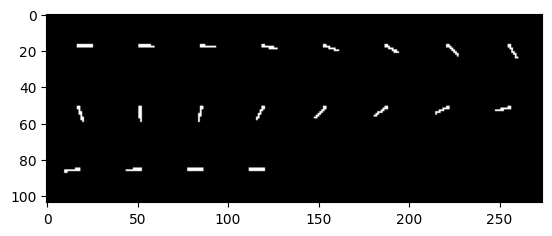

In [9]:
# data trajectory
b_ind = 2
print(X.shape)
grid = utils.make_grid(X[:, b_ind].view(-1, 1, 32, 32))
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([60, 256, 32, 32])


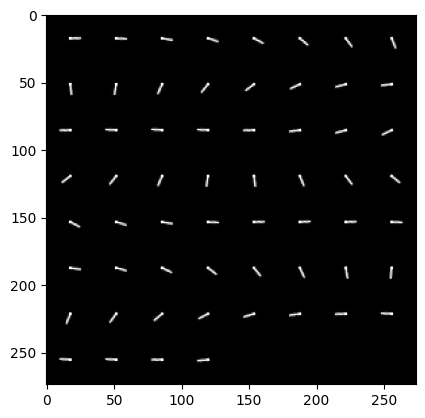

In [10]:
# prediction trajectory
print(model.Xrec.shape)
grid = utils.make_grid(model.Xrec[:, b_ind].view(-1, 1, 32, 32))
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

## Plot learned potential energy

In [11]:
q = np.linspace(0, 2*np.pi, 41)
cos_q = np.cos(q[:-1])
sin_q = np.sin(q[:-1])
cos_q_sin_q = np.stack((cos_q, sin_q), axis=1)
cos_q_sin_q = torch.tensor(cos_q_sin_q, dtype=torch.float32)

Text(0, 0.5, '$V(\\phi)$')

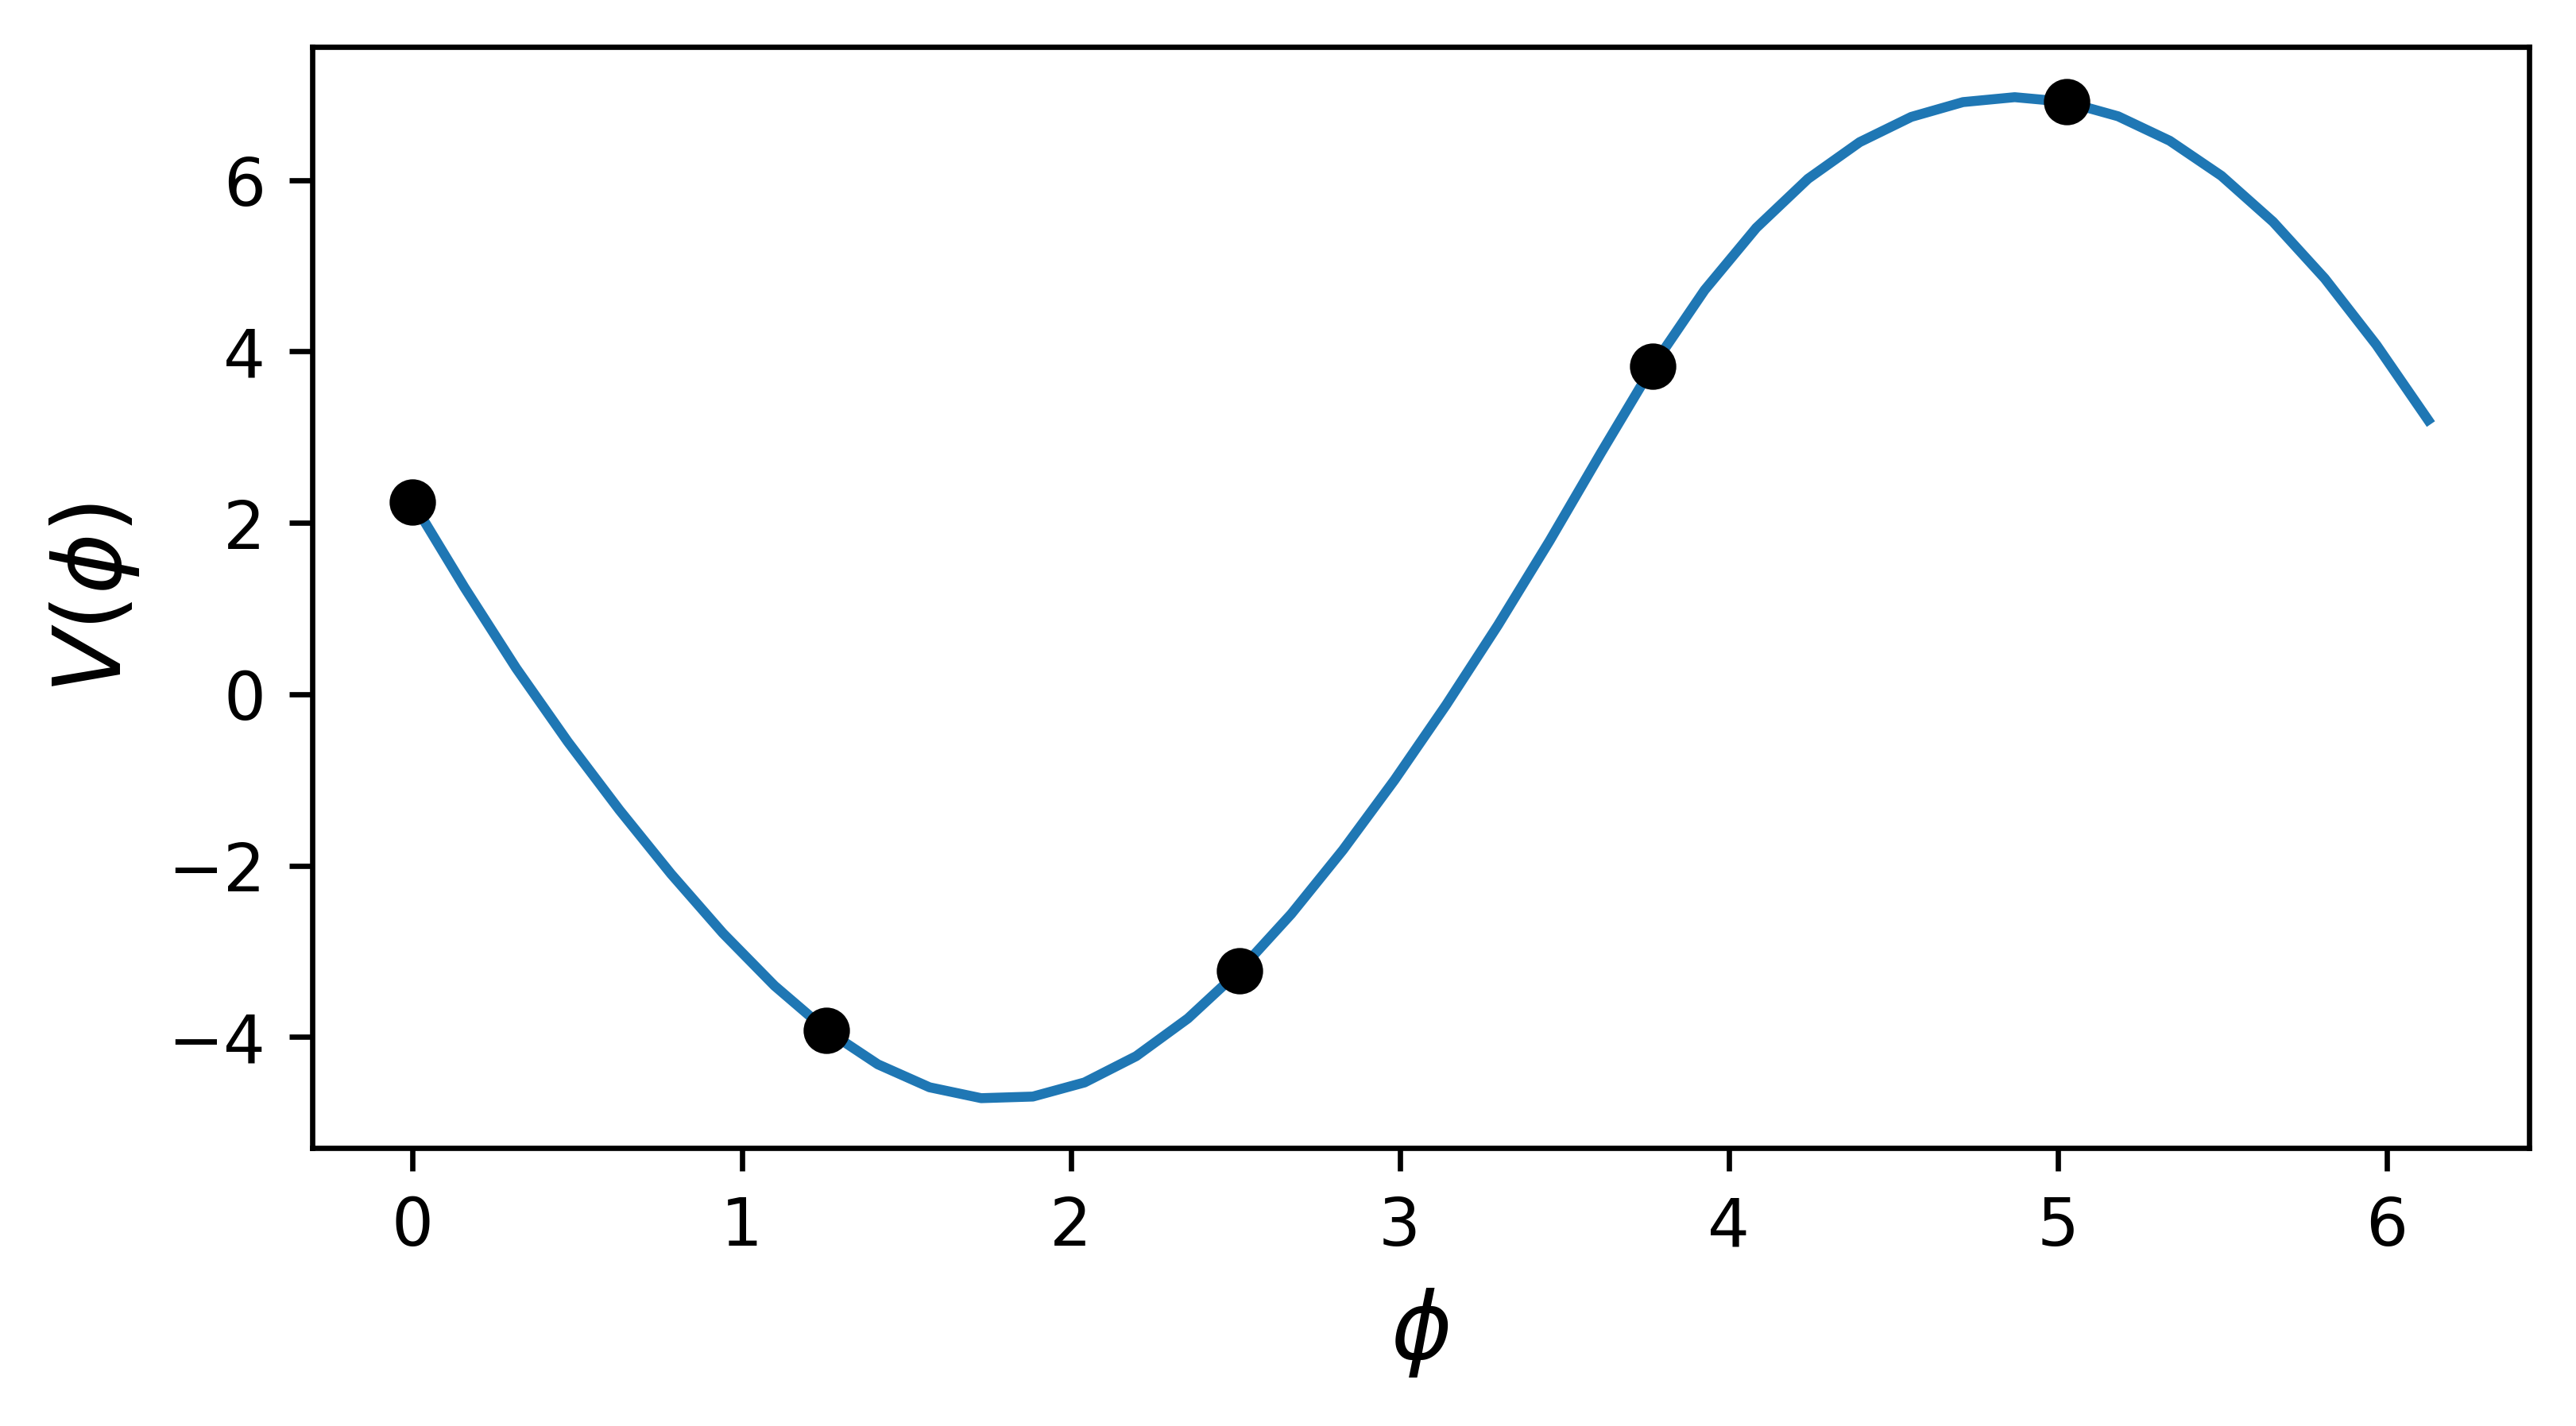

In [12]:
V_q = model.ode.V_net(cos_q_sin_q).detach().cpu().numpy()
fig = plt.figure(figsize=[6, 3], dpi=DPI)
markers_on = [0, 8, 16, 24, 32]
plt.plot(q[:-1], V_q, marker = 'o', markevery=markers_on, markerfacecolor=(0,0,0,1), markeredgecolor=(0,0,0,1))
plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$V(\phi)$", fontsize=14)
# plt.tight_layout()
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend_potential_energy'), bbox_inches='tight')

## Plot 5 reconstruction images corresponding to the black dots

/usr/local/lib/python3.8/site-packages/torch/nn/functional.py:4358: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/torch/nn/functional.py:4296: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([60, 256, 32, 32])
torch.Size([40, 1, 32, 32])


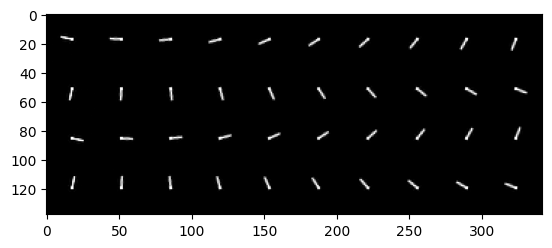

In [13]:
ones = torch.ones_like(cos_q_sin_q[:, 0:1])
content = model.obs_net(ones)

theta = model.get_theta_inv(cos_q_sin_q[:, 0], cos_q_sin_q[:, 1], 0, 0, bs=cos_q_sin_q.shape[0])
grid = F.affine_grid(theta, torch.Size((40, 1, 32, 32)))
Xrec = F.grid_sample(content.view(40, 1, 32, 32), grid)
print(model.Xrec.shape)
print(Xrec.shape)
fig = plt.figure()
grid = utils.make_grid(Xrec.view(40, 1, 32, 32), nrow=10)
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


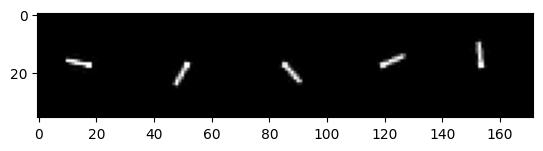

In [14]:
# for i in [0, 8, 16, 24, 32]:
#     fig = plt.figure()
#     plt.imshow(Xrec[i][0].detach().cpu().numpy(), cmap='gray')
#     plt.axis('off')
#     fig.savefig(os.path.join(PARENT_DIR, 'figures', f'pend_recon_{i}.png'), bbox_inches='tight')
grid = utils.make_grid(Xrec[0:40:8])
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

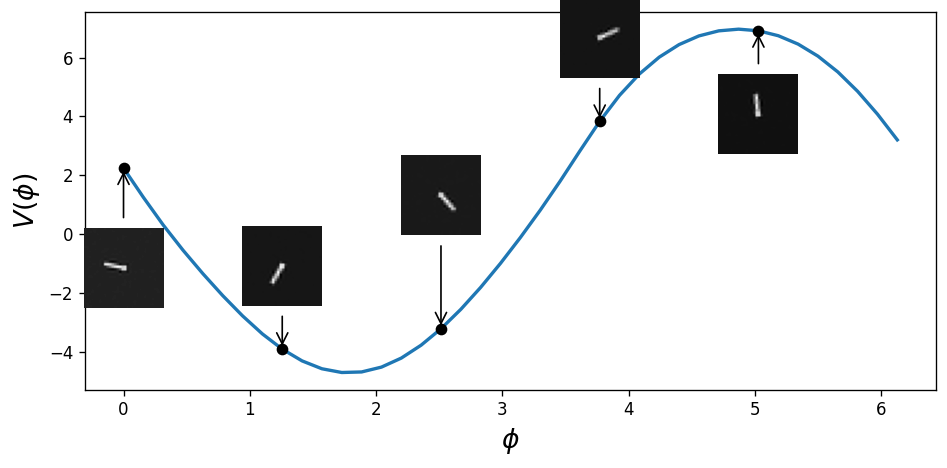

In [15]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# ... (Run your existing data generation code for q, V_q, and Xrec here) ...

# 1. Setup the main figure
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

# 2. Plot the Potential Energy Curve
markers_on = [0, 8, 16, 24, 32]
ax.plot(q[:-1], V_q, marker='o', markevery=markers_on, 
        markerfacecolor='black', markeredgecolor='black', linewidth=2)

ax.set_xlabel(r"$\phi$", fontsize=16)
ax.set_ylabel(r"$V(\phi)$", fontsize=16)

# 3. Define offsets for the images to match the visual style of your upload
# (dx, dy) in 'points' relative to the data point. 
# You can tweak these to move the images up/down/left/right.
offsets = [
    (0, -60),  # Index 0:  Move image Down
    (0, 50),   # Index 8:  Move image Up
    (0, 80),   # Index 16: Move image Up (Longer arrow for the valley)
    (0, 50),   # Index 24: Move image Up
    (0, -50)   # Index 32: Move image Down
]

# 4. Loop through markers and overlay images
for i, idx in enumerate(markers_on):
    # Get the coordinate on the curve
    x_curr = q[idx]
    y_curr = V_q[idx]
    
    # Extract the image from Xrec (assuming shape [N, C, H, W])
    # We take the first channel [0] to get a 2D array (32x32)
    img_array = Xrec[idx, 0].detach().cpu().numpy()
    
    # Create an off-set image box
    # zoom controls the size of the thumbnail
    imagebox = OffsetImage(img_array, zoom=1.5, cmap='gray') 
    
    # Create the annotation
    # xy is the data point (dot), xybox is where the image sits
    ab = AnnotationBbox(imagebox, (x_curr, y_curr),
                        xybox=offsets[i],
                        boxcoords="offset points",
                        arrowprops=dict(arrowstyle="->", color='black'),
                        frameon=False) # Remove the box border around the image
    
    ax.add_artist(ab)

# Clean up layout
plt.tight_layout()
plt.show()

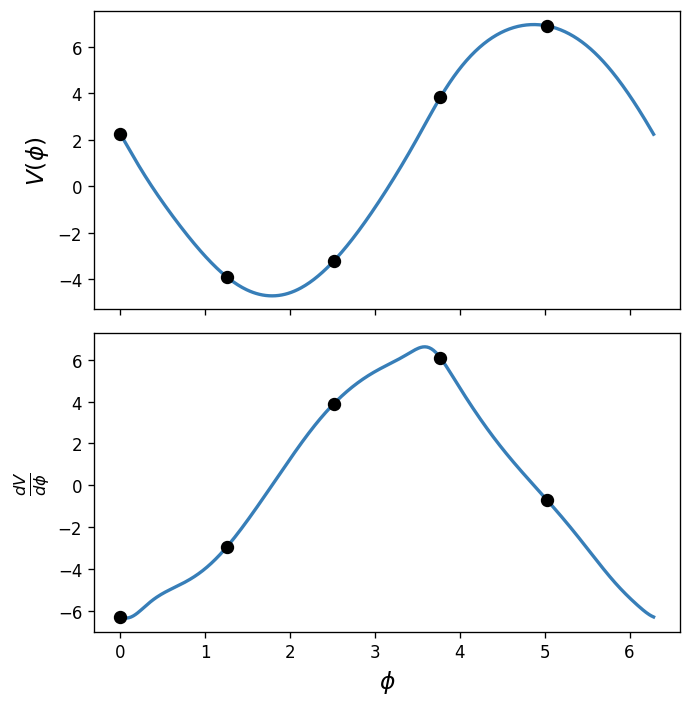

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# User's constants
DPI = 120

# ==========================================
# 1. PREPARE DATA
# ==========================================

# --- A. Dense Grid (For the smooth blue curve) ---
# We use 500 points to ensure the line looks like a curve, not polygons.
q_dense_np = np.linspace(0, 2*np.pi, 500)
q_dense = torch.tensor(q_dense_np, dtype=torch.float32, requires_grad=True)

# Compute inputs on the dense grid
cos_dense = torch.cos(q_dense)
sin_dense = torch.sin(q_dense)
x_dense = torch.stack((cos_dense, sin_dense), dim=1)


# --- B. Sparse Grid (For the black markers) ---
# This matches your original 40-point resolution logic
q_sparse_np = np.linspace(0, 2*np.pi, 41)[:-1] 
q_sparse = torch.tensor(q_sparse_np, dtype=torch.float32, requires_grad=True)

# Compute inputs on the sparse grid
cos_sparse = torch.cos(q_sparse)
sin_sparse = torch.sin(q_sparse)
x_sparse = torch.stack((cos_sparse, sin_sparse), dim=1)


# ==========================================
# 2. MODEL PASS & AUTOGRAD
# ==========================================
model.eval() # Important: Disables Dropout/BatchNorm noise

def get_V_and_grad(q_input, x_input):
    """Helper to forward pass and calculate gradient for any input resolution."""
    # 1. Forward Pass
    V_pred = model.ode.V_net(x_input)
    
    # 2. Backward Pass (Gradient)
    # We differentiate V_pred w.r.t q_input
    grads = torch.autograd.grad(
        outputs=V_pred,
        inputs=q_input,
        grad_outputs=torch.ones_like(V_pred),
        create_graph=False
    )[0]
    
    return V_pred.detach().cpu().numpy(), grads.detach().cpu().numpy()

# Calculate smooth curves
V_curve, dV_curve = get_V_and_grad(q_dense, x_dense)

# Calculate specific marker points
V_markers, dV_markers = get_V_and_grad(q_sparse, x_sparse)


# ==========================================
# 3. PLOTTING
# ==========================================
fig, ax = plt.subplots(2, 1, figsize=[6, 6], dpi=DPI, sharex=True)
markers_idx = [0, 8, 16, 24, 32] # Indices for the sparse array

# --- Top Plot: V(phi) ---
# 1. Plot the high-res line (Smooth)
ax[0].plot(q_dense_np, V_curve, color='#377eb8', linewidth=2)
# 2. Overlay the low-res markers
ax[0].plot(q_sparse_np[markers_idx], V_markers[markers_idx], 
           marker='o', linestyle='None', # 'None' prevents drawing lines between dots
           markerfacecolor='black', markeredgecolor='black', markersize=7)
ax[0].set_ylabel(r"$V(\phi)$", fontsize=14)

# --- Bottom Plot: dV/dphi ---
# 1. Plot the high-res line (Smooth) - THIS FIXES THE KINKS
ax[1].plot(q_dense_np, dV_curve, color='#377eb8', linewidth=2)
# 2. Overlay the low-res markers
ax[1].plot(q_sparse_np[markers_idx], dV_markers[markers_idx], 
           marker='o', linestyle='None', 
           markerfacecolor='black', markeredgecolor='black', markersize=7)
ax[1].set_ylabel(r"$\frac{dV}{d\phi}$", fontsize=14)
ax[1].set_xlabel(r"$\phi$", fontsize=14)

plt.tight_layout()
plt.show()

# Control

In [16]:
import gym, myenv
import numpy as np
from skimage import color
from gym import wrappers
env = gym.make('MyPendulum-v0')

# prepare model instance
model.hparams.solver = 'rk4'
model.bs = 1
model.d = 32

# get a goal image
q_star = 0.0
env.reset()
env.state = np.array([q_star, 0.0], dtype=np.float32)
goal_frame = env.render(mode='rgb_array')
goal_frame = color.rgb2gray(goal_frame)
goal_frame = torch.tensor(goal_frame, dtype=torch.float32)
env.close()

# given a goal image, design controller
# first encode the goal image to goal coordinates
_, _, goal_q_n = model.encode(goal_frame.view(1, 32*32))

/usr/local/lib/python3.8/site-packages/gym/logger.py:30: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize('%s: %s'%('WARN', msg % args), 'yellow'))


NoSuchDisplayException: Cannot connect to "None"

In [ ]:
goal_q_n

In [ ]:
q0 = 3.14

env.reset()
env.state = np.array([q0, 0.0], dtype=np.float32)
frame = color.rgb2gray(env.render(mode='rgb_array'))
frames = [frame]

frame = torch.tensor(frame, dtype=torch.float32)

for i in range(100):
    _, _, q_n = model.encode(frame.view(1, 32*32))
    
    if i==0:
        prev_q_n = q_n
        
    q_dot = model.angle_vel_est(prev_q_n, q_n, 0.05)

    V_q = model.ode.V_net(q_n)
    dV = torch.autograd.grad(V_q, q_n)[0]
    dV_dcos_q, dV_dsin_q = dV.split([1, 1], dim=1)
    dV_dq = - dV_dcos_q * q_n[:, 1] + dV_dsin_q * q_n[:, 0]
    g_q = model.ode.g_net(q_n)

#     energy_shaping = torch.zeros(2, 1, dtype=torch.float32)
#     energy_shaping[0][0] = dV_dr[0][0] - 3* (r_cos_phi_sin_phi[0][0] - 0.0)
#     energy_shaping[1][0] = 2 * dV_dphi[0][0]

    energy_shaping = dV_dq - 6 * (q_n[0, 1] * goal_q_n[0, 0] - q_n[0, 0] * goal_q_n[0, 1])
    damping_injection = - 1 * q_dot.T

    u = 1/g_q * (energy_shaping + damping_injection)

    u = u.detach().cpu().numpy()
    env.step(u)

    frame = color.rgb2gray(env.render(mode='rgb_array'))
    frames.append(frame)
    frame = torch.tensor(frame, dtype=torch.float32)

    prev_q_n = q_n

env.close()

In [ ]:
fig = plt.figure(figsize=(16, 4), dpi=DPI)
for i in range(13):
    plt.subplot(1, 13, i+1)
    plt.imshow(frames[i*8], cmap='gray')
    plt.axis('off')
    
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend-ctrl.png'), bbox_inches='tight')

In [ ]:
# import imageio
# imageio.mimsave(os.path.join(PARENT_DIR, 'figures', 'pend-ctrl.gif'), frames, duration=0.05)

control animation ![control sequence](../figures/pend-ctrl.gif)

In [17]:
model.hparams

"T_pred":                            4
"accelerator":                       None
"accumulate_grad_batches":           None
"amp_backend":                       native
"amp_level":                         None
"annealing":                         False
"auto_lr_find":                      False
"auto_scale_batch_size":             False
"auto_select_gpus":                  False
"batch_size":                        512
"benchmark":                         False
"check_val_every_n_epoch":           1
"checkpoint_callback":               None
"default_root_dir":                  None
"detect_anomaly":                    False
"deterministic":                     False
"devices":                           None
"enable_checkpointing":              True
"enable_model_summary":              True
"enable_progress_bar":               True
"fast_dev_run":                      False
"flush_logs_every_n_steps":          None
"gpus":                              1
"gradient_clip_algorithm":        